## Making trees work - Exercise
```In this exercise you will experience with Decision Trees and Random Forests. During this part you will explore the different features of them and will plot your results. Hence, whenever exploration tasks are marked with (*), know that you are asked to plot two graphs (on the same plot): the training score against the explored feature and the test score against it.```

```~Ittai Haran```

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from supervised_init import LOGGER, RANDOM_SEED
from supervised_utils import make_local_weight_function

%matplotlib inline

DATA_DIRECTORY = Path.cwd().parent
OUTPUT_DIRECTORY = Path("outputs") / datetime.now().strftime("exercise_4_%Y%m%d_%H%M%S")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=False)
plt.style.use("seaborn-v0_8-whitegrid")
LOGGER.info("Output directory: %s", OUTPUT_DIRECTORY.resolve())

Output directory: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\supervised\exercise\outputs\exercise_4_20260825_172537


```Read the dataset. In this dataset, you are provided over a hundred variables describing attributes of life insurance applicants. The task is to predict the "Response" variable.```

```the dataset can be found in: ```https://drive.google.com/open?id=1t_P64gM1M1_c2n4PvH7AZoELH2CNh6ui

In [2]:
insurance_data = pd.read_csv(
    filepath_or_buffer=DATA_DIRECTORY / "insurance_fixed.csv"
)
insurance_features = insurance_data.drop(columns="Response")
insurance_target = insurance_data["Response"]

(
    insurance_features_train,
    insurance_features_test,
    insurance_target_train,
    insurance_target_test,
) = train_test_split(
    insurance_features,
    insurance_target,
    train_size=0.70,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=insurance_target,
)

LOGGER.info(
    "Insurance data: %d rows, %d predictors, %d response classes",
    insurance_data.shape[0],
    insurance_features.shape[1],
    insurance_target.nunique(),
)
(
    insurance_features_exploration,
    insurance_features_exploration_remainder,
    insurance_target_exploration,
    insurance_target_exploration_remainder,
) = train_test_split(
    insurance_features_train,
    insurance_target_train,
    train_size=15_000,
    random_state=RANDOM_SEED,
    stratify=insurance_target_train,
)
LOGGER.info(
    "Hyperparameter exploration subset: %d rows",
    len(insurance_features_exploration),
)

Insurance data: 59381 rows, 125 predictors, 8 response classes
Hyperparameter exploration subset: 15000 rows


```We will start by using Decision trees. Use a simple DecisionTreeClassifier with default values to predict on your train and on your test. Evaluate the model using the accuracy metric, which you can find in sklearn.```

In [3]:
# The required classifiers and metrics are imported in the initialization cell.

In [4]:
unrestricted_tree = DecisionTreeClassifier(random_state=RANDOM_SEED)
unrestricted_tree.fit(X=insurance_features_train, y=insurance_target_train)

unrestricted_tree_train_accuracy = accuracy_score(
    y_true=insurance_target_train,
    y_pred=unrestricted_tree.predict(X=insurance_features_train),
)
unrestricted_tree_test_accuracy = accuracy_score(
    y_true=insurance_target_test,
    y_pred=unrestricted_tree.predict(X=insurance_features_test),
)
LOGGER.info("Unrestricted tree training accuracy: %.4f", unrestricted_tree_train_accuracy)
LOGGER.info("Unrestricted tree test accuracy: %.4f", unrestricted_tree_test_accuracy)

Unrestricted tree training accuracy: 1.0000
Unrestricted tree test accuracy: 0.4249


**Answer.** Training accuracy is 1.0000 while test accuracy is 0.4249. The large gap shows that the unrestricted tree severely overfits.

```Unfortunately, you are at overfit. Now let's try to get better. Try playing with the max depth of the tree, for``` $1\leq depth \leq25$ ```(*) (This means you are asked to plot some graphs, remember? :) )```

```Choose the optimal max_depth based on the graph you got.```

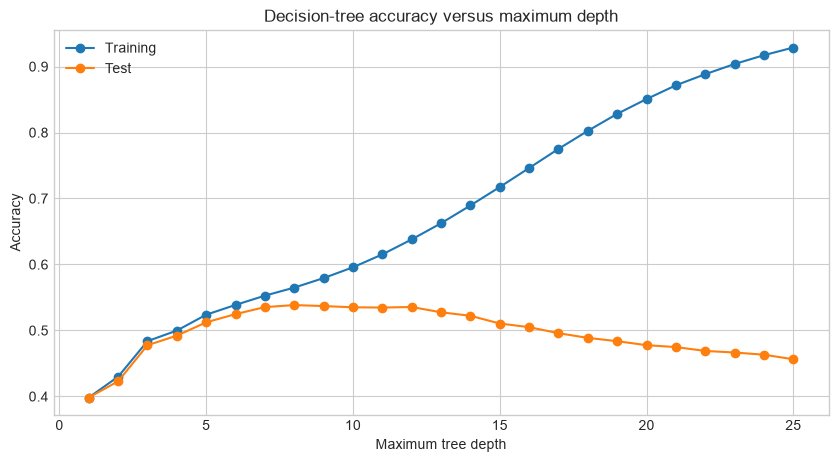

Best observed decision-tree depth: 8 (test accuracy 0.5385)


In [5]:
tree_depth_values = np.arange(start=1, stop=26)
tree_train_accuracies = []
tree_test_accuracies = []

for current_tree_depth in tree_depth_values:
    depth_tree = DecisionTreeClassifier(
        max_depth=int(current_tree_depth),
        random_state=RANDOM_SEED,
    )
    depth_tree.fit(X=insurance_features_train, y=insurance_target_train)
    tree_train_accuracies.append(
        accuracy_score(
            y_true=insurance_target_train,
            y_pred=depth_tree.predict(X=insurance_features_train),
        )
    )
    tree_test_accuracies.append(
        accuracy_score(
            y_true=insurance_target_test,
            y_pred=depth_tree.predict(X=insurance_features_test),
        )
    )

best_tree_depth = int(tree_depth_values[int(np.argmax(a=tree_test_accuracies))])
best_tree_test_accuracy = float(np.max(a=tree_test_accuracies))

plt.figure(figsize=(10, 5))
plt.plot(tree_depth_values, tree_train_accuracies, marker="o", label="Training")
plt.plot(tree_depth_values, tree_test_accuracies, marker="o", label="Test")
plt.xlabel("Maximum tree depth")
plt.ylabel("Accuracy")
plt.title("Decision-tree accuracy versus maximum depth")
plt.legend()
plt.show()
LOGGER.info(
    "Best observed decision-tree depth: %d (test accuracy %.4f)",
    best_tree_depth,
    best_tree_test_accuracy,
)

**Answer.** The best observed test accuracy is 0.5385 at `max_depth=8`, so 8 is the selected depth.

```Choose the best max_depth you found. Now try playing with min_samples_leaf. use the following values:
[1, 10, 100, 300,700, 1000]. Do it also with max_depth = 20. What can we learn from the graphs? Please answer the question ```$\ \underline{in\ another\ cell}$```.(*)```

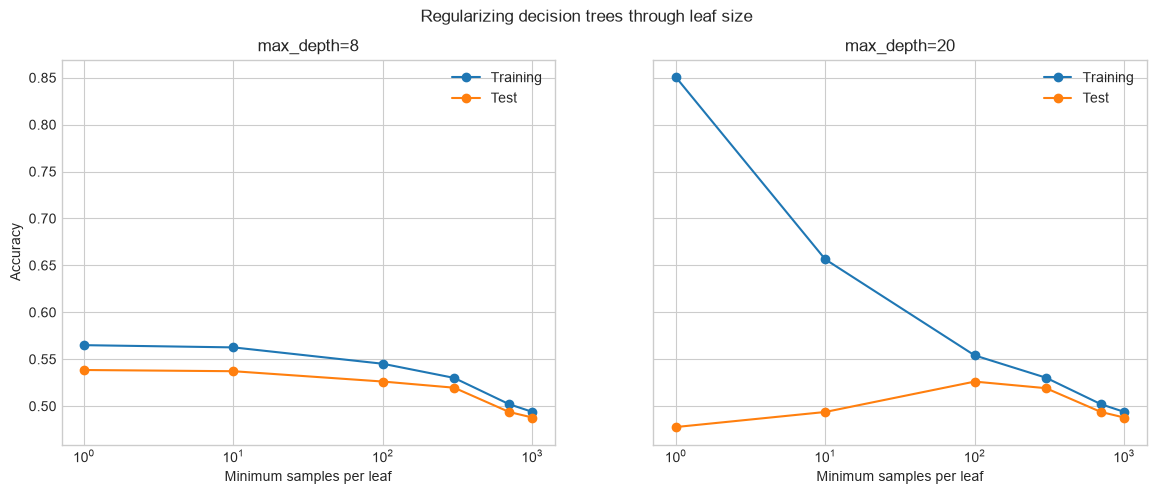

Selected tree: max_depth=8, min_samples_leaf=1, test accuracy=0.5385


In [6]:
minimum_leaf_values = [1, 10, 100, 300, 700, 1000]
leaf_results = []

figure, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), sharey=True)
for axis, current_maximum_depth in zip(axes, [best_tree_depth, 20]):
    current_train_accuracies = []
    current_test_accuracies = []
    for current_minimum_leaf_size in minimum_leaf_values:
        leaf_tree = DecisionTreeClassifier(
            max_depth=current_maximum_depth,
            min_samples_leaf=current_minimum_leaf_size,
            random_state=RANDOM_SEED,
        )
        leaf_tree.fit(X=insurance_features_train, y=insurance_target_train)
        current_train_accuracy = accuracy_score(
            y_true=insurance_target_train,
            y_pred=leaf_tree.predict(X=insurance_features_train),
        )
        current_test_accuracy = accuracy_score(
            y_true=insurance_target_test,
            y_pred=leaf_tree.predict(X=insurance_features_test),
        )
        current_train_accuracies.append(current_train_accuracy)
        current_test_accuracies.append(current_test_accuracy)
        leaf_results.append(
            {
                "max_depth": current_maximum_depth,
                "min_samples_leaf": current_minimum_leaf_size,
                "train_accuracy": current_train_accuracy,
                "test_accuracy": current_test_accuracy,
            }
        )
    axis.plot(minimum_leaf_values, current_train_accuracies, marker="o", label="Training")
    axis.plot(minimum_leaf_values, current_test_accuracies, marker="o", label="Test")
    axis.set_xscale("log")
    axis.set_title(f"max_depth={current_maximum_depth}")
    axis.set_xlabel("Minimum samples per leaf")
    axis.legend()
axes[0].set_ylabel("Accuracy")
figure.suptitle("Regularizing decision trees through leaf size")
plt.show()

leaf_results_frame = pd.DataFrame(data=leaf_results)
best_leaf_result = leaf_results_frame.loc[leaf_results_frame["test_accuracy"].idxmax()]
best_tree_depth = int(best_leaf_result["max_depth"])
best_tree_minimum_leaf_size = int(best_leaf_result["min_samples_leaf"])
best_tree_test_accuracy = float(best_leaf_result["test_accuracy"])
LOGGER.info(
    "Selected tree: max_depth=%d, min_samples_leaf=%d, test accuracy=%.4f",
    best_tree_depth,
    best_tree_minimum_leaf_size,
    best_tree_test_accuracy,
)

**Answer.** Increasing `min_samples_leaf` regularizes the tree: training accuracy falls and the train–test gap narrows. Depth 20 overfits with small leaves, while depth 8 is already constrained. Very large leaves underfit; the selected setting is `max_depth=8, min_samples_leaf=1` for this split.

```Decision Tree is a very nice algorithm, especially because it is very intuitive and explainable. We can even draw it!
Train a simple Decision Tree with max_depth = 3. Call it basic_tree and run the cell below. Examine the file tree.png you created.```

In [7]:
basic_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_SEED)
basic_tree.fit(X=insurance_features_train, y=insurance_target_train);

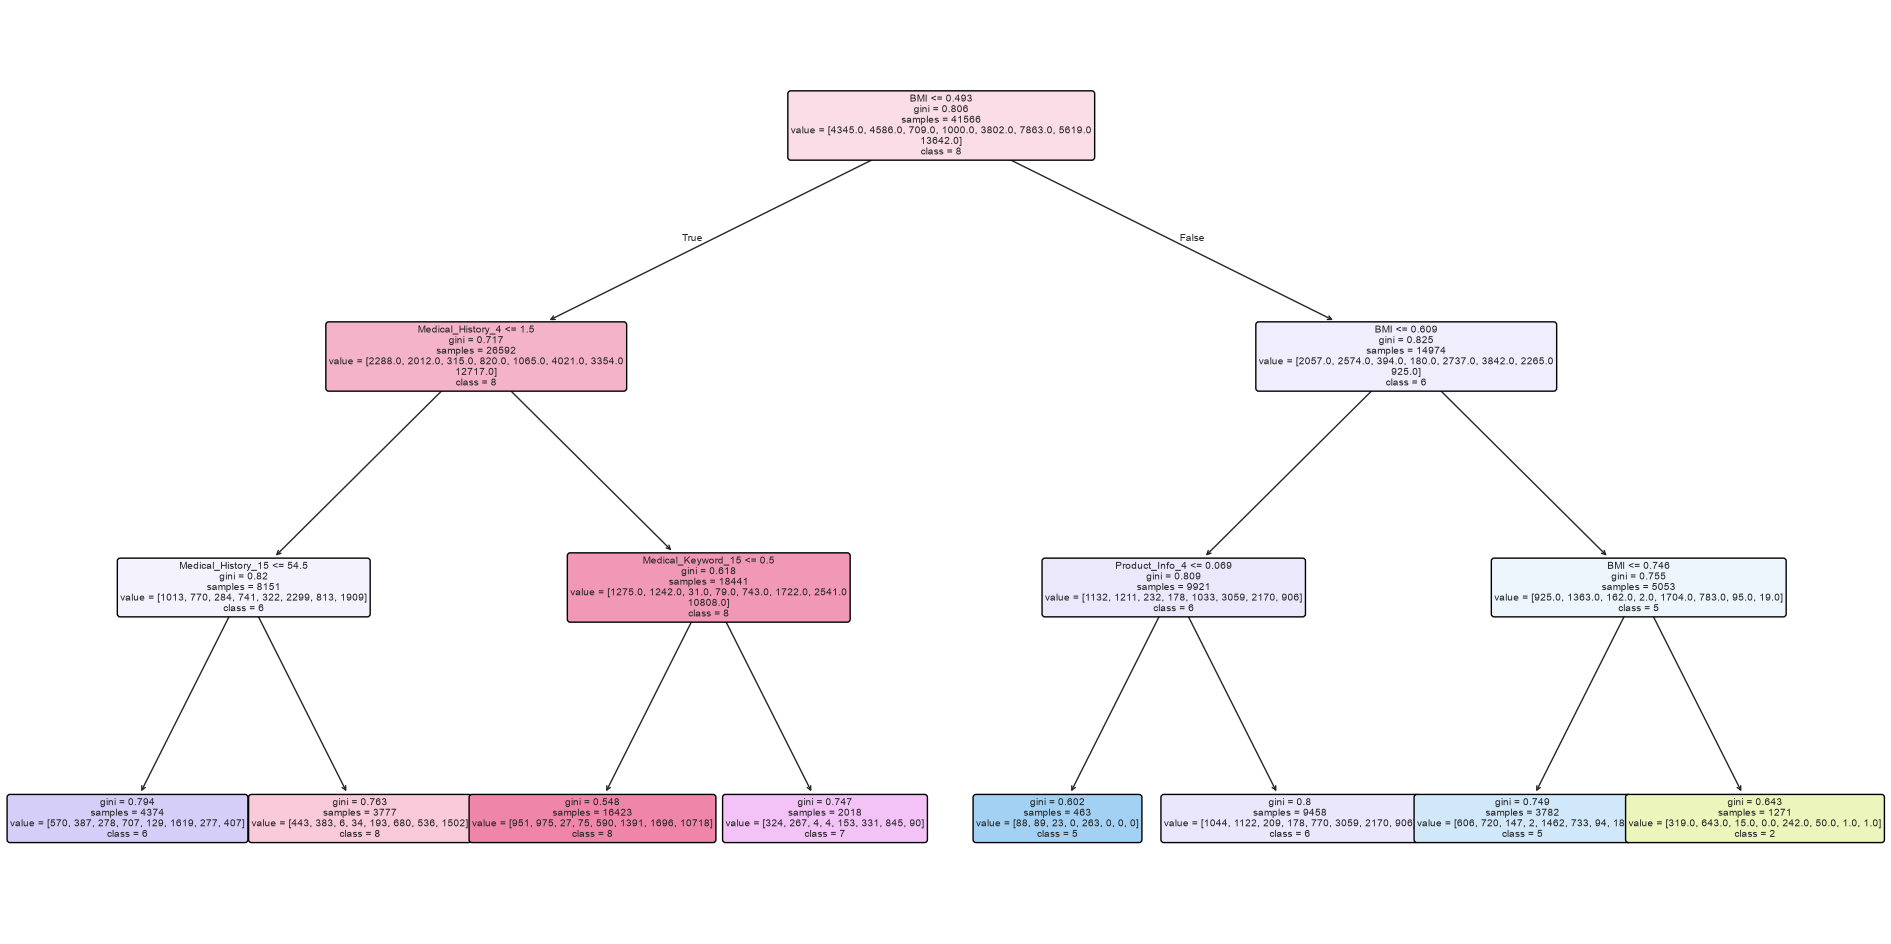

Saved tree visualization: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\supervised\exercise\outputs\exercise_4_20260825_172537\tree.png


In [8]:
tree_figure = plt.figure(figsize=(24, 12))
plot_tree(
    decision_tree=basic_tree,
    feature_names=list(insurance_features.columns),
    class_names=[str(class_label) for class_label in basic_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=7,
)
tree_image_path = OUTPUT_DIRECTORY / "tree.png"
tree_figure.savefig(fname=tree_image_path, dpi=180, bbox_inches="tight")
plt.show()
LOGGER.info("Saved tree visualization: %s", tree_image_path.resolve())

```Look at the tree you got. What, would you say, are the most important features?
As you recall, we talked about feature importance in the lecture notes. Use the attribute feature_importance_ of your tree to get a list of the most important features.```

In [9]:
basic_tree_importance = (
    pd.DataFrame(
        data={
            "feature": insurance_features.columns,
            "importance": basic_tree.feature_importances_,
        }
    )
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)
display(basic_tree_importance.head(n=15))

,feature,importance
0,BMI,0.537200
1,Medical_History_4,0.190477
2,Medical_Keyword_15,0.172319
3,Medical_History_15,0.064279
4,Product_Info_4,0.035724
5,Product_Info_6,0.000000
6,Product_Info_7,0.000000
7,Ht,0.000000
8,Ins_Age,0.000000
9,Wt,0.000000


**Answer.** The depth-3 tree relies most on `BMI`, followed by `Medical_History_4`, `Medical_Keyword_15`, `Medical_History_15`, and `Product_Info_4`.

```We will now move to Random Forest. Repeat the exlporations tasks with a Random forest with 100 trees (max depth and min samples leaf). In addition, vary the number of trees between 10 and 400, while maintaining low max_depth (*) and the max_feature parameter, between 0.1 and 1 (*). Try explaining the graphs you see ```$\ \underline{in\ a\ different\ cell}$```. Use the flag n_jobs = -1 in your experiments to accelerate your computation time. Make sure to understand where your model is overfitted.```

In [10]:
# RandomForestClassifier is imported in the initialization cell.

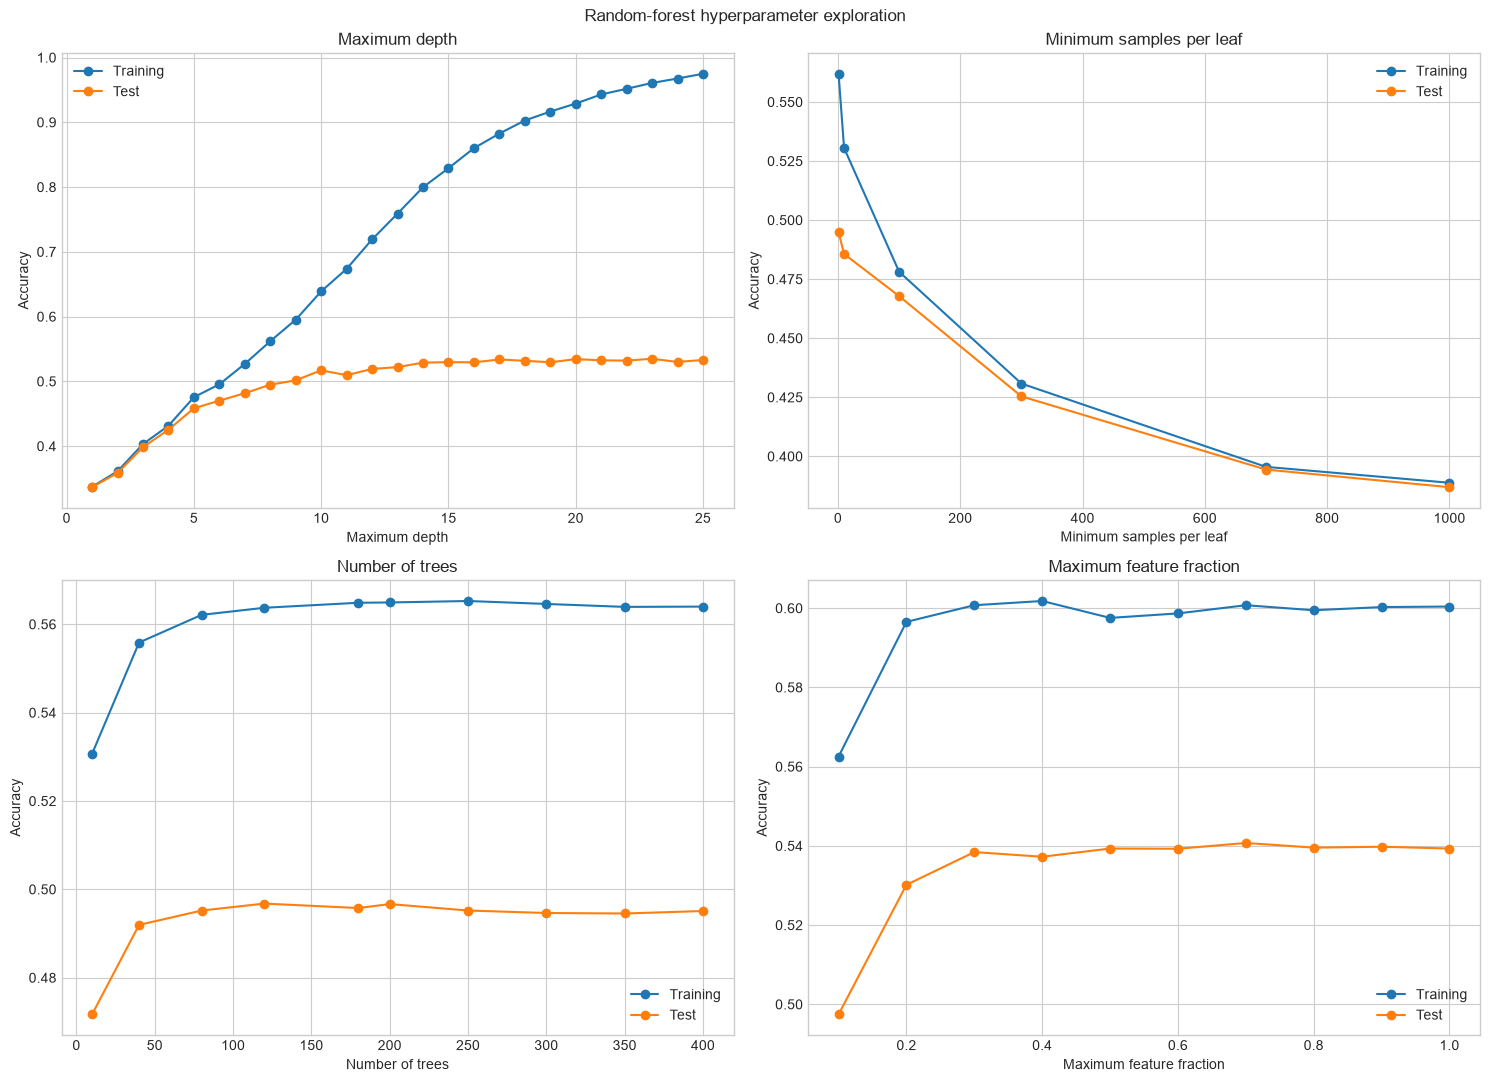

In [11]:
forest_depth_values = list(range(1, 26))
forest_leaf_values = [1, 10, 100, 300, 700, 1000]
forest_tree_count_values = [10, 40, 80, 120, 180, 200, 250, 300, 350, 400]
forest_max_feature_values = [
    round(float(current_feature_fraction), 1)
    for current_feature_fraction in np.arange(start=0.1, stop=1.1, step=0.1)
]

forest_experiments = [
    {
        "name": "Maximum depth",
        "values": forest_depth_values,
        "parameter_name": "max_depth",
    },
    {
        "name": "Minimum samples per leaf",
        "values": forest_leaf_values,
        "parameter_name": "min_samples_leaf",
    },
    {
        "name": "Number of trees",
        "values": forest_tree_count_values,
        "parameter_name": "n_estimators",
    },
    {
        "name": "Maximum feature fraction",
        "values": forest_max_feature_values,
        "parameter_name": "max_features",
    },
]

forest_experiment_results = {}
figure, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 11))
for axis, experiment_configuration in zip(axes.ravel(), forest_experiments):
    experiment_name = experiment_configuration["name"]
    experiment_values = experiment_configuration["values"]
    parameter_name = experiment_configuration["parameter_name"]
    current_train_accuracies = []
    current_test_accuracies = []

    for experiment_value in experiment_values:
        current_parameters = {
            "n_estimators": 100,
            "max_depth": best_tree_depth,
            "min_samples_leaf": 1,
            "max_features": "sqrt",
        }
        current_parameters[parameter_name] = experiment_value
        current_forest = RandomForestClassifier(
            **current_parameters,
            n_jobs=-1,
            random_state=RANDOM_SEED,
        )
        current_forest.fit(
            X=insurance_features_exploration,
            y=insurance_target_exploration,
        )
        current_train_accuracies.append(
            accuracy_score(
                y_true=insurance_target_exploration,
                y_pred=current_forest.predict(X=insurance_features_exploration),
            )
        )
        current_test_accuracies.append(
            accuracy_score(
                y_true=insurance_target_test,
                y_pred=current_forest.predict(X=insurance_features_test),
            )
        )

    forest_experiment_results[experiment_name] = {
        "values": experiment_values,
        "train": current_train_accuracies,
        "test": current_test_accuracies,
    }
    axis.plot(
        experiment_values,
        current_train_accuracies,
        marker="o",
        label="Training",
    )
    axis.plot(
        experiment_values,
        current_test_accuracies,
        marker="o",
        label="Test",
    )
    axis.set_title(experiment_name)
    axis.set_xlabel(experiment_name)
    axis.set_ylabel("Accuracy")
    axis.legend()

figure.suptitle("Random-forest hyperparameter exploration")
figure.tight_layout()
plt.show()

best_forest_depth = forest_depth_values[
    int(np.argmax(a=forest_experiment_results["Maximum depth"]["test"]))
]
best_forest_minimum_leaf_size = forest_leaf_values[
    int(np.argmax(a=forest_experiment_results["Minimum samples per leaf"]["test"]))
]
best_forest_tree_count = forest_tree_count_values[
    int(np.argmax(a=forest_experiment_results["Number of trees"]["test"]))
]
best_forest_max_features = forest_max_feature_values[
    int(np.argmax(a=forest_experiment_results["Maximum feature fraction"]["test"]))
]

**Answer.** Greater depth raises training accuracy and eventually widens the train–test gap; larger leaves regularize the model. Adding trees mainly stabilizes validation accuracy, while high `max_features` reduces tree diversity.

```As you could see, at least one of your graphs turned out to be very noisy. Use K Fold cross validation to evalute your model more accurately. In K Fold cross validation we split our data into K segments, and for each ```$\ 1\leq i\leq K\ $``` we test our model on the i-th segment while training it using the others.```

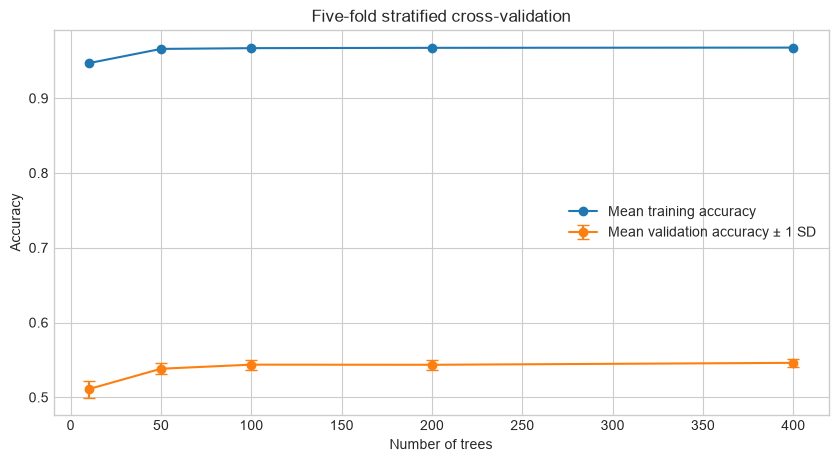

CV-selected number of trees: 400


In [12]:
cross_validation_tree_counts = [10, 50, 100, 200, 400]
stratified_folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED,
)
cross_validation_train_means = []
cross_validation_test_means = []
cross_validation_test_standard_deviations = []

for current_tree_count in cross_validation_tree_counts:
    cross_validation_forest = RandomForestClassifier(
        n_estimators=current_tree_count,
        max_depth=best_forest_depth,
        min_samples_leaf=best_forest_minimum_leaf_size,
        max_features=best_forest_max_features,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    )
    fold_scores = cross_validate(
        estimator=cross_validation_forest,
        X=insurance_features_exploration,
        y=insurance_target_exploration,
        cv=stratified_folds,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=1,
    )
    cross_validation_train_means.append(float(np.mean(a=fold_scores["train_score"])))
    cross_validation_test_means.append(float(np.mean(a=fold_scores["test_score"])))
    cross_validation_test_standard_deviations.append(
        float(np.std(a=fold_scores["test_score"]))
    )

best_forest_tree_count = int(
    cross_validation_tree_counts[int(np.argmax(a=cross_validation_test_means))]
)
plt.figure(figsize=(10, 5))
plt.plot(
    cross_validation_tree_counts,
    cross_validation_train_means,
    marker="o",
    label="Mean training accuracy",
)
plt.errorbar(
    cross_validation_tree_counts,
    cross_validation_test_means,
    yerr=cross_validation_test_standard_deviations,
    marker="o",
    capsize=4,
    label="Mean validation accuracy ± 1 SD",
)
plt.xlabel("Number of trees")
plt.ylabel("Accuracy")
plt.title("Five-fold stratified cross-validation")
plt.legend()
plt.show()
LOGGER.info("CV-selected number of trees: %d", best_forest_tree_count)

```Use the Random Forest to surpass the best score you got using Decision Tree.```

In [13]:
best_random_forest = RandomForestClassifier(
    n_estimators=best_forest_tree_count,
    max_depth=best_forest_depth,
    min_samples_leaf=best_forest_minimum_leaf_size,
    max_features=best_forest_max_features,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
best_random_forest.fit(X=insurance_features_train, y=insurance_target_train)
best_forest_test_accuracy = accuracy_score(
    y_true=insurance_target_test,
    y_pred=best_random_forest.predict(X=insurance_features_test),
)
LOGGER.info("Best decision-tree test accuracy: %.4f", best_tree_test_accuracy)
LOGGER.info("Selected random-forest test accuracy: %.4f", best_forest_test_accuracy)
LOGGER.info(
    "Random-forest improvement: %+.4f",
    best_forest_test_accuracy - best_tree_test_accuracy,
)

Best decision-tree test accuracy: 0.5385
Selected random-forest test accuracy: 0.5631
Random-forest improvement: +0.0246


**Answer.** The selected random forest reaches 0.5631 test accuracy versus 0.5385 for the best decision tree, an improvement of 0.0246.

## Extra thinking on feature importance

```We talked about feature importance in the lecture notes. get the feature importance of each feature using a decision tree and using a random forest. Use in both cases the best hyper parameters you found so far. Discuss the differences between the answers``` $\underline{in\ a\ cell}$.

,feature,decision_tree_importance,random_forest_importance
9,BMI,0.352584,0.140777
8,Wt,0.018475,0.052303
2,Product_Info_4,0.100723,0.052193
6,Ins_Age,0.035494,0.050077
10,Employment_Info_1,0.003727,0.039908
39,Medical_History_4,0.125118,0.039704
50,Medical_History_15,0.066647,0.035607
37,Medical_History_2,0.001428,0.032692
36,Medical_History_1,0.003470,0.031367
15,Employment_Info_6,0.001860,0.028157


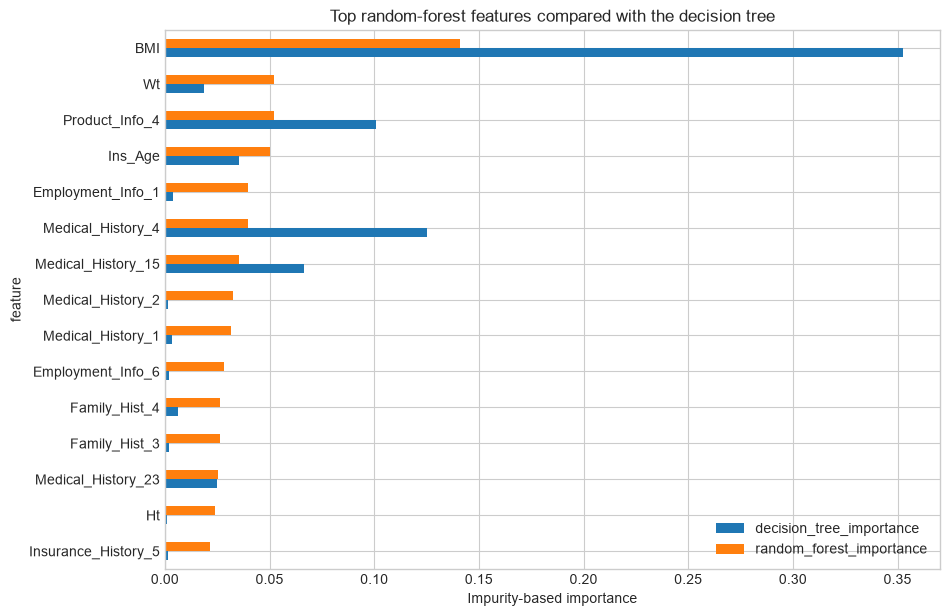

In [14]:
best_decision_tree = DecisionTreeClassifier(
    max_depth=best_tree_depth,
    min_samples_leaf=best_tree_minimum_leaf_size,
    random_state=RANDOM_SEED,
)
best_decision_tree.fit(X=insurance_features_train, y=insurance_target_train)

importance_comparison = pd.DataFrame(
    data={
        "feature": insurance_features.columns,
        "decision_tree_importance": best_decision_tree.feature_importances_,
        "random_forest_importance": best_random_forest.feature_importances_,
    }
)
display(
    importance_comparison.sort_values(
        by="random_forest_importance", ascending=False
    ).head(n=20)
)

top_importance_comparison = importance_comparison.nlargest(
    n=15, columns="random_forest_importance"
).sort_values(by="random_forest_importance")
top_importance_comparison.plot.barh(
    x="feature",
    y=["decision_tree_importance", "random_forest_importance"],
    figsize=(10, 7),
)
plt.xlabel("Impurity-based importance")
plt.title("Top random-forest features compared with the decision tree")
plt.show()

**Answer.** A single tree concentrates importance in a few early splits, so its ranking is less stable. The forest averages across many trees and spreads importance among correlated substitutes. These impurity-based values describe model usage, not causality.

```We can define a concept of feature importance for linear regression: Suppose you have two features, ```$x_1$ ```and``` $x_2$. ```Suppose that you got a linear regression of the form```

$y = 100\cdot x_1 + 1\cdot x_2$

```What feature is more important? What if we have -100 instead of 100? Generalize this idea to any number of features. Train a linear regression on your data and get the feature importances.```

In [15]:
standardized_linear_model = make_pipeline(
    StandardScaler(),
    LinearRegression(n_jobs=-1),
)
standardized_linear_model.fit(
    X=insurance_features_train,
    y=insurance_target_train,
)
standardized_coefficients = standardized_linear_model.named_steps[
    "linearregression"
].coef_
linear_feature_importance = (
    pd.DataFrame(
        data={
            "feature": insurance_features.columns,
            "coefficient": standardized_coefficients,
            "absolute_importance": np.abs(standardized_coefficients),
        }
    )
    .sort_values(by="absolute_importance", ascending=False)
    .reset_index(drop=True)
)
display(linear_feature_importance.head(n=20))

,feature,coefficient,absolute_importance
0,Medical_History_4,0.573395,0.573395
1,Medical_History_15,0.387418,0.387418
2,Wt,-0.374308,0.374308
3,Medical_History_23,0.370100,0.370100
4,BMI,-0.362708,0.362708
5,Medical_Keyword_3,-0.327245,0.327245
6,Ins_Age,-0.249121,0.249121
7,Product_Info_4,0.222453,0.222453
8,Ht,0.190154,0.190154
9,Medical_History_30,-0.189192,0.189192


**Answer.** After standardization, coefficients of 100 and −100 are equally important but act in opposite directions. The sign gives direction; `abs(coefficient)` gives strength for any number of features.

## Feature selection
```We will now try using the feature_importance we can get from our models to do a wise feature selection.```

Do the following:



*   ```Take the best Random Forest model you got at the last part.```
*   ```Select the top 20 feature with the greatest feature importance.```
*   ```Train a KNN model with n_neighbors = 8 (and n_jobs = -1). What is its accuracy?```
*   ```Train a KNN model using the 20 features you found, again with n_neighbors = 8 (and n_jobs = -1). What is its accuracy? What can we learn from it?```
*   ```Repeat the two last tasks, this time with the best Random Forest configuration you found. Can you explain the results?```
*   ```Draw a graph where the y axis is a feature_importance sum, and the x axis is the number of features you must take to get this sum. How can this graph help you to explain your results?```

,model,features,accuracy
0,KNN,All,0.393400
1,KNN,Top 20,0.433200
2,Random forest,All,0.563065
3,Random forest,Top 20,0.538816


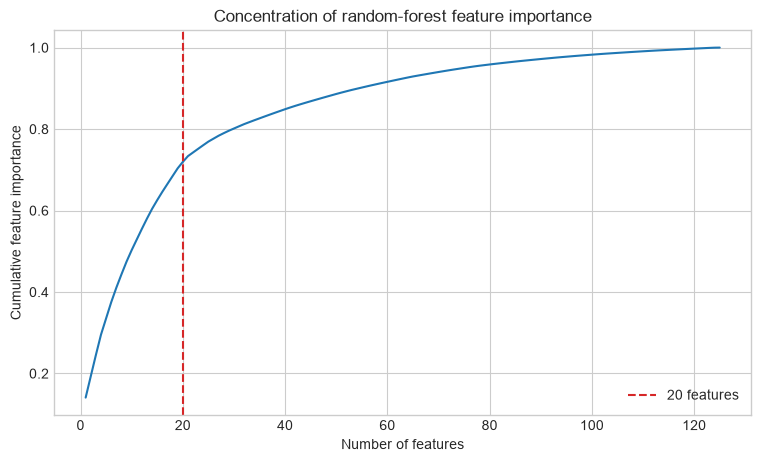

In [16]:
top_twenty_features = (
    importance_comparison.nlargest(n=20, columns="random_forest_importance")["feature"]
    .tolist()
)

(
    knn_features_train,
    knn_features_train_remainder,
    knn_target_train,
    knn_target_train_remainder,
) = train_test_split(
    insurance_features_train,
    insurance_target_train,
    train_size=15_000,
    random_state=RANDOM_SEED,
    stratify=insurance_target_train,
)
(
    knn_features_test,
    knn_features_test_remainder,
    knn_target_test,
    knn_target_test_remainder,
) = train_test_split(
    insurance_features_test,
    insurance_target_test,
    train_size=5_000,
    random_state=RANDOM_SEED,
    stratify=insurance_target_test,
)

knn_all_features = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=8, n_jobs=-1),
)
knn_all_features.fit(X=knn_features_train, y=knn_target_train)
knn_all_accuracy = accuracy_score(
    y_true=knn_target_test,
    y_pred=knn_all_features.predict(X=knn_features_test),
)

knn_top_features = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=8, n_jobs=-1),
)
knn_top_features.fit(
    X=knn_features_train[top_twenty_features],
    y=knn_target_train,
)
knn_top_accuracy = accuracy_score(
    y_true=knn_target_test,
    y_pred=knn_top_features.predict(X=knn_features_test[top_twenty_features]),
)

forest_top_features = RandomForestClassifier(
    n_estimators=best_forest_tree_count,
    max_depth=best_forest_depth,
    min_samples_leaf=best_forest_minimum_leaf_size,
    max_features=best_forest_max_features,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
forest_top_features.fit(
    X=insurance_features_train[top_twenty_features],
    y=insurance_target_train,
)
forest_top_accuracy = accuracy_score(
    y_true=insurance_target_test,
    y_pred=forest_top_features.predict(X=insurance_features_test[top_twenty_features]),
)

feature_selection_results = pd.DataFrame(
    data={
        "model": ["KNN", "KNN", "Random forest", "Random forest"],
        "features": ["All", "Top 20", "All", "Top 20"],
        "accuracy": [
            knn_all_accuracy,
            knn_top_accuracy,
            best_forest_test_accuracy,
            forest_top_accuracy,
        ],
    }
)
display(feature_selection_results)

sorted_forest_importance = np.sort(a=best_random_forest.feature_importances_)[::-1]
cumulative_forest_importance = np.cumsum(a=sorted_forest_importance)
plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(start=1, stop=len(cumulative_forest_importance) + 1),
    cumulative_forest_importance,
)
plt.axvline(x=20, color="tab:red", linestyle="--", label="20 features")
plt.xlabel("Number of features")
plt.ylabel("Cumulative feature importance")
plt.title("Concentration of random-forest feature importance")
plt.legend()
plt.show()

**Answer.** KNN improved from 0.3934 to 0.4332 with the top 20 features because removing weak dimensions makes distance more informative. The forest fell from 0.5631 to 0.5388 because discarded features still supplied useful splits or interactions. The cumulative-importance curve shows how quickly predictive importance concentrates.

```We will now implement a primitive reduction of Seffi's feature selection method (you are encouraged to ask him about it):```
- ```Take the best Random Forest model you found.```
- ```Create a dictionary that holds {feature: its importance}.```
- ```Transpose the df matrix, so we may think on the columns as 'samples' and vice versa.```
- ```Normalize each 'sample', so its length is 1.```
- ```Use KMeans with n_clusters = 20 on the 'samples'.```
- ```From each cluster take the feature with the highest feature importance.```

In [17]:
feature_importance_by_name = dict(
    zip(insurance_features.columns, best_random_forest.feature_importances_)
)
transposed_features = insurance_features_train.transpose()
normalized_transposed_features = Normalizer(norm="l2").fit_transform(
    X=transposed_features
)
feature_cluster_model = KMeans(
    n_clusters=20,
    random_state=RANDOM_SEED,
    n_init=20,
)
feature_cluster_labels = feature_cluster_model.fit_predict(
    X=normalized_transposed_features
)
clustered_features = pd.DataFrame(
    data={
        "feature": transposed_features.index,
        "cluster": feature_cluster_labels,
        "importance": [
            feature_importance_by_name[feature_name]
            for feature_name in transposed_features.index
        ],
    }
)
cluster_selected_features = (
    clustered_features.sort_values(by="importance", ascending=False)
    .groupby(by="cluster", as_index=False)
    .first()["feature"]
    .tolist()
)

knn_cluster_features = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=8, n_jobs=-1),
)
knn_cluster_features.fit(
    X=knn_features_train[cluster_selected_features],
    y=knn_target_train,
)
knn_cluster_accuracy = accuracy_score(
    y_true=knn_target_test,
    y_pred=knn_cluster_features.predict(
        X=knn_features_test[cluster_selected_features]
    ),
)

cluster_comparison = pd.DataFrame(
    data={
        "feature_set": ["All features", "Top 20 by importance", "20 cluster representatives"],
        "knn_accuracy": [knn_all_accuracy, knn_top_accuracy, knn_cluster_accuracy],
    }
)
display(cluster_comparison)
display(clustered_features.sort_values(by=["cluster", "importance"], ascending=[True, False]))

,feature_set,knn_accuracy
0,All features,0.3934
1,Top 20 by importance,0.4332
2,20 cluster representatives,0.3696


,feature,cluster,importance
100,Medical_Keyword_24,0,0.001528
9,BMI,1,0.140777
8,Wt,1,0.052303
2,Product_Info_4,1,0.052193
6,Ins_Age,1,0.050077
...,...,...,...
88,Medical_Keyword_12,15,0.000795
90,Medical_Keyword_14,16,0.000631
120,Medical_Keyword_44,17,0.000514
96,Medical_Keyword_20,18,0.000595


**Answer.** The top-20 importance set performed best at 0.4332; cluster representatives scored 0.3696. Clustering promotes diversity but can select weak representatives. Standardizing each feature across applicants and clustering by correlation would make similarity more meaningful.

## Ensemble methods and stacking
```In this part we will explore the concept of model stacking: that is, training a model, the combining model, on the outputs of several other models. Hence, the stacking method has two steps: first we train our models, and than we train the combining model using the outputs of those models.```

```In the setting of stacking models it is very important to train the several models on one segment of the data and train the combining model on another segment. Hence, start by splitting the data to 3 segments: train_1 segment, 35% of the data, train_2 segment, 35% of the data, and test segment, the last 30% of the data.```

In [18]:
(
    stacking_features_development,
    stacking_features_test,
    stacking_target_development,
    stacking_target_test,
) = train_test_split(
    insurance_features,
    insurance_target,
    train_size=0.70,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=insurance_target,
)
(
    stacking_features_train_1,
    stacking_features_train_2,
    stacking_target_train_1,
    stacking_target_train_2,
) = train_test_split(
    stacking_features_development,
    stacking_target_development,
    train_size=0.50,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=stacking_target_development,
)
LOGGER.info(
    "Stacking split sizes: train_1=%d, train_2=%d, test=%d",
    len(stacking_features_train_1),
    len(stacking_features_train_2),
    len(stacking_features_test),
)

Stacking split sizes: train_1=20783, train_2=20783, test=17815


```Our first experiment is as follows: train a random forest of simple decision trees (30 trees, max_depth = 3), using train_1. Use the estimators of the forest to create 30*8=240 features: for each estimator get the probabilities it gives for the target to belong to any of the classes. You can get the list of the estimators using RandomForestClassifier.estimators_ and have the probabilities mentioned using model.predict_proba.
Using the new features you got (and them only), train a logistic regression (LogisticRegression).
Compare between the accuracy of the first random forest (on the test segment) and the accuracy of the stacked models (again, on the test segment).```

In [19]:
# The ensemble, linear-model, and metric imports are centralized above.

In [20]:
shallow_forest = RandomForestClassifier(
    n_estimators=30,
    max_depth=3,
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
shallow_forest.fit(X=stacking_features_train_1, y=stacking_target_train_1)

shallow_meta_train_features = np.concatenate(
    [
        estimator.predict_proba(X=stacking_features_train_2.to_numpy())
        for estimator in shallow_forest.estimators_
    ],
    axis=1,
)
shallow_meta_test_features = np.concatenate(
    [
        estimator.predict_proba(X=stacking_features_test.to_numpy())
        for estimator in shallow_forest.estimators_
    ],
    axis=1,
)
shallow_combiner = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
shallow_combiner.fit(X=shallow_meta_train_features, y=stacking_target_train_2)

shallow_forest_probabilities = shallow_forest.predict_proba(X=stacking_features_test)
shallow_stacked_probabilities = shallow_combiner.predict_proba(X=shallow_meta_test_features)
LOGGER.info(
    "Shallow forest: accuracy=%.4f, log loss=%.4f",
    accuracy_score(
        y_true=stacking_target_test,
        y_pred=shallow_forest.predict(X=stacking_features_test),
    ),
    log_loss(y_true=stacking_target_test, y_pred=shallow_forest_probabilities),
)
LOGGER.info(
    "Tree-output stack: accuracy=%.4f, log loss=%.4f",
    accuracy_score(
        y_true=stacking_target_test,
        y_pred=shallow_combiner.predict(X=shallow_meta_test_features),
    ),
    log_loss(y_true=stacking_target_test, y_pred=shallow_stacked_probabilities),
)

Shallow forest: accuracy=0.3986, log loss=1.6127
Tree-output stack: accuracy=0.5117, log loss=1.3534


**Answer.** Stacking the 3 tree-probability outputs raises test accuracy from 0.3986 to 0.5117 and lowers log loss from 1.6127 to 1.3534.

```We will conduct a similar experiment: create a set of at least 5 different models, of different kinds - use algorithms we talked about in the course. Stack them to get a better model. Compare the accuracies of the models to the accuracy of your stacked model.```

In [21]:
# Five heterogeneous classifiers are constructed in the next cell.

In [22]:
base_models = {
    "Decision tree": DecisionTreeClassifier(
        max_depth=best_tree_depth,
        min_samples_leaf=best_tree_minimum_leaf_size,
        random_state=RANDOM_SEED,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=best_forest_tree_count,
        max_depth=best_forest_depth,
        min_samples_leaf=best_forest_minimum_leaf_size,
        max_features=best_forest_max_features,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "KNN": make_pipeline(
        ColumnTransformer(
            transformers=[
                ("selected_features", "passthrough", top_twenty_features)
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        ),
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=8, n_jobs=-1),
    ),
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    ),
    "Gaussian NB": GaussianNB(),
}

base_model_results = []
meta_train_blocks = []
meta_test_blocks = []
for model_name, current_model in base_models.items():
    current_model.fit(X=stacking_features_train_1, y=stacking_target_train_1)
    current_test_probabilities = current_model.predict_proba(X=stacking_features_test)
    meta_train_blocks.append(current_model.predict_proba(X=stacking_features_train_2))
    meta_test_blocks.append(current_test_probabilities)
    base_model_results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(
                y_true=stacking_target_test,
                y_pred=current_model.predict(X=stacking_features_test),
            ),
            "macro_ovr_auc": roc_auc_score(
                y_true=stacking_target_test,
                y_score=current_test_probabilities,
                multi_class="ovr",
                average="macro",
            ),
        }
    )

heterogeneous_meta_train_features = np.concatenate(meta_train_blocks, axis=1)
heterogeneous_meta_test_features = np.concatenate(meta_test_blocks, axis=1)
heterogeneous_combiner = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
)
heterogeneous_combiner.fit(
    X=heterogeneous_meta_train_features,
    y=stacking_target_train_2,
)
heterogeneous_stacked_probabilities = heterogeneous_combiner.predict_proba(
    X=heterogeneous_meta_test_features
)
base_model_results.append(
    {
        "model": "Stacked model",
        "accuracy": accuracy_score(
            y_true=stacking_target_test,
            y_pred=heterogeneous_combiner.predict(X=heterogeneous_meta_test_features),
        ),
        "macro_ovr_auc": roc_auc_score(
            y_true=stacking_target_test,
            y_score=heterogeneous_stacked_probabilities,
            multi_class="ovr",
            average="macro",
        ),
    }
)
stacking_results = pd.DataFrame(data=base_model_results).sort_values(
    by="macro_ovr_auc", ascending=False
)
display(stacking_results)

,model,accuracy,macro_ovr_auc
5,Stacked model,0.560314,0.845488
1,Random forest,0.550042,0.835719
3,Logistic regression,0.500646,0.807814
0,Decision tree,0.535167,0.787309
2,KNN,0.439180,0.712039
4,Gaussian NB,0.274319,0.675777


**Answer.** The heterogeneous stack performs best: accuracy is 0.5603 and macro one-vs-rest AUC is 0.8455, exceeding every base model. The random forest is the strongest base model at 0.5500 accuracy and 0.8357 AUC.

```As we said earlier, it is very important use two different train segments. What happens if you use the same train segment in both steps of the stacked model? Note that you now use more data to train your models, and also your combining model. Do you get better results? Do it and explain your results ```$\underline{\ in\ a\ cell\ below.}$

In [23]:
leaky_base_models = {
    "Decision tree": DecisionTreeClassifier(
        max_depth=best_tree_depth,
        min_samples_leaf=best_tree_minimum_leaf_size,
        random_state=RANDOM_SEED,
    ),
    "Random forest": RandomForestClassifier(
        n_estimators=best_forest_tree_count,
        max_depth=best_forest_depth,
        min_samples_leaf=best_forest_minimum_leaf_size,
        max_features=best_forest_max_features,
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    "KNN": make_pipeline(
        ColumnTransformer(
            transformers=[
                ("selected_features", "passthrough", top_twenty_features)
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        ),
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=8, n_jobs=-1),
    ),
    "Logistic regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    ),
    "Gaussian NB": GaussianNB(),
}

leaky_meta_train_blocks = []
leaky_meta_test_blocks = []
for current_model in leaky_base_models.values():
    current_model.fit(X=stacking_features_development, y=stacking_target_development)
    leaky_meta_train_blocks.append(
        current_model.predict_proba(X=stacking_features_development)
    )
    leaky_meta_test_blocks.append(current_model.predict_proba(X=stacking_features_test))

leaky_meta_train_features = np.concatenate(leaky_meta_train_blocks, axis=1)
leaky_meta_test_features = np.concatenate(leaky_meta_test_blocks, axis=1)
leaky_combiner = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
leaky_combiner.fit(X=leaky_meta_train_features, y=stacking_target_development)

LOGGER.info(
    "Same-segment stack training accuracy: %.4f",
    accuracy_score(
        y_true=stacking_target_development,
        y_pred=leaky_combiner.predict(X=leaky_meta_train_features),
    ),
)
LOGGER.info(
    "Same-segment stack test accuracy: %.4f",
    accuracy_score(
        y_true=stacking_target_test,
        y_pred=leaky_combiner.predict(X=leaky_meta_test_features),
    ),
)

Same-segment stack training accuracy: 0.9795
Same-segment stack test accuracy: 0.5086


**Answer.** Reusing the same segment leaks in-sample base-model behavior into the combiner: training accuracy rises to 0.9795, but test accuracy is only 0.5086. Proper stacking uses a disjoint segment or out-of-fold predictions.

## Extrapolation in Decision Trees

In [24]:
sine_features_train = np.linspace(start=0.0, stop=5.0, num=83).reshape(-1, 1)
sine_target_train = np.sin(sine_features_train).ravel()
sine_features_interpolation = np.arange(start=0.0, stop=5.0, step=0.01).reshape(-1, 1)

`Try to approximate the sine function using a decision tree regressor.
Use the tree's depth to get a more accurate approximation of the sine function. Plot the results (try at least 3 differents depths).`

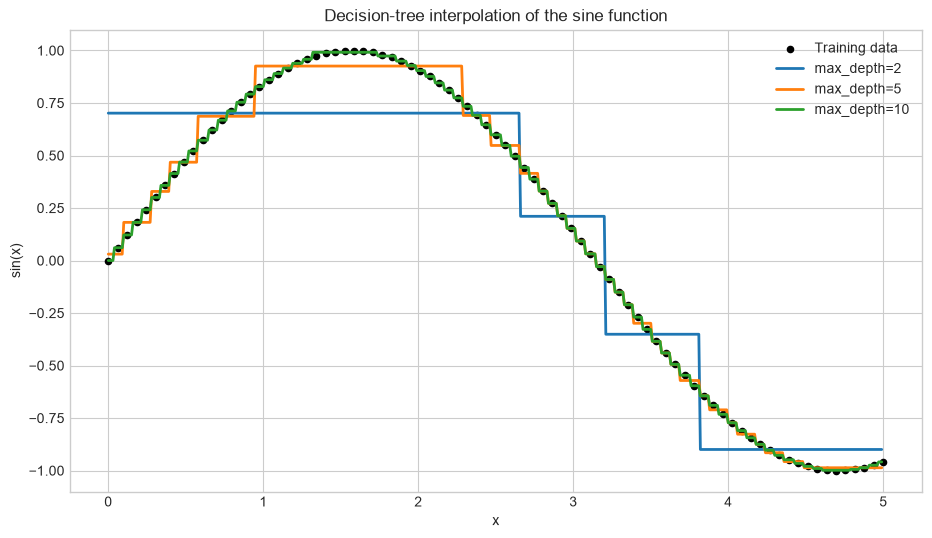

In [25]:
regression_depth_values = [2, 5, 10]
sine_tree_models = {}

plt.figure(figsize=(11, 6))
plt.scatter(
    sine_features_train.ravel(),
    sine_target_train,
    s=20,
    color="black",
    label="Training data",
)
for current_regression_depth in regression_depth_values:
    current_sine_tree = DecisionTreeRegressor(
        max_depth=current_regression_depth,
        random_state=RANDOM_SEED,
    )
    current_sine_tree.fit(X=sine_features_train, y=sine_target_train)
    sine_tree_models[current_regression_depth] = current_sine_tree
    plt.plot(
        sine_features_interpolation.ravel(),
        current_sine_tree.predict(X=sine_features_interpolation),
        linewidth=2,
        label=f"max_depth={current_regression_depth}",
    )
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Decision-tree interpolation of the sine function")
plt.legend()
plt.show()

`We now define a new test set, with values out of the training set.
Try the Decision Tree regressor on this new test set.
Plot the obtained results.`

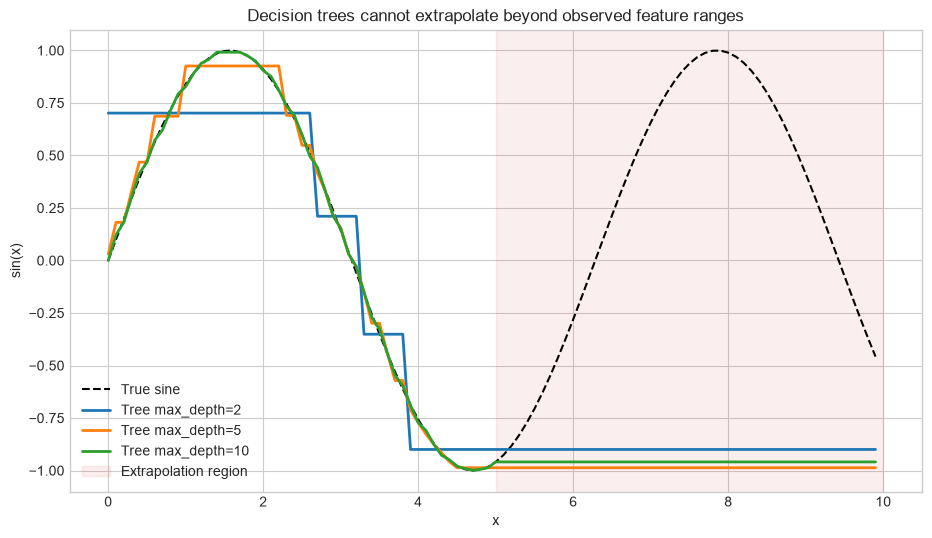

In [26]:
sine_features_extrapolation = np.arange(
    start=0.0, stop=10.0, step=0.1
).reshape(-1, 1)
sine_target_extrapolation = np.sin(sine_features_extrapolation).ravel()

plt.figure(figsize=(11, 6))
plt.plot(
    sine_features_extrapolation.ravel(),
    sine_target_extrapolation,
    color="black",
    linestyle="--",
    label="True sine",
)
for current_regression_depth, current_sine_tree in sine_tree_models.items():
    plt.plot(
        sine_features_extrapolation.ravel(),
        current_sine_tree.predict(X=sine_features_extrapolation),
        linewidth=2,
        label=f"Tree max_depth={current_regression_depth}",
    )
plt.axvspan(xmin=5.0, xmax=10.0, color="tab:red", alpha=0.08, label="Extrapolation region")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Decision trees cannot extrapolate beyond observed feature ranges")
plt.legend()
plt.show()

`Can you explain this phenomenon? How does the training of the tree causes it?`

**Answer.** A regression tree stores a constant target mean in each terminal leaf. Every value beyond the training range follows the same threshold path and lands in the same leaf, so the prediction stays flat instead of continuing the sine wave.

`What other model you know could overcome this situation?`

**Answer.** A linear model using Fourier features such as $\sin(x)$ and $\cos(x)$ can extrapolate this periodic pattern. Polynomial regression can also extrapolate, but high-degree polynomials may be unstable outside the fitted range.

## Model explaining- LIMING things up
```We will try to explain complicated models using Decision Trees, and will get to know some concepts in the field.```

```We will use the MNIST data set.```

In [27]:
mnist_data = pd.read_csv(filepath_or_buffer=DATA_DIRECTORY / "MNIST_train.csv")
mnist_target = mnist_data["label"]
mnist_features = mnist_data.drop(columns="label")
(
    mnist_features_train,
    mnist_features_test,
    mnist_target_train,
    mnist_target_test,
) = train_test_split(
    mnist_features,
    mnist_target,
    train_size=0.70,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=mnist_target,
)
LOGGER.info(
    "MNIST split: %d training images and %d test images",
    len(mnist_features_train),
    len(mnist_features_test),
)

MNIST split: 29399 training images and 12600 test images


```Train a LGBMClassifier on the data set, using max_depth=10, n_estimators=250 (and, of course, n_jobs = -1). How good is your model?```

The requested LightGBM classifier is used directly. Its fixed seed makes this training run reproducible, while `n_jobs=-1` lets LightGBM use the available CPU cores.

In [28]:
mnist_black_box = LGBMClassifier(
    max_depth=10,
    n_estimators=250,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=-1,
)
mnist_black_box.fit(X=mnist_features_train, y=mnist_target_train)
mnist_train_accuracy = accuracy_score(
    y_true=mnist_target_train,
    y_pred=mnist_black_box.predict(X=mnist_features_train),
)
mnist_test_accuracy = accuracy_score(
    y_true=mnist_target_test,
    y_pred=mnist_black_box.predict(X=mnist_features_test),
)
LOGGER.info("MNIST black-box training accuracy: %.4f", mnist_train_accuracy)
LOGGER.info("MNIST black-box test accuracy: %.4f", mnist_test_accuracy)

MNIST black-box training accuracy: 1.0000
MNIST black-box test accuracy: 0.9763


**Answer.** LightGBM reaches 1.0000 training accuracy and 0.9763 test accuracy, so it generalizes well despite fitting the training set perfectly.

```Read The short paper Model-Agnostic Interpretability of Machine Learning by Riberio et al, which you can find in the papers directory. We are about to try to make the LIME method proposed in the paper work, using Decision Tree. We would like to train a simple and interpretable model that predicts, locally, the predictions of our LGBMClassifier.
Create the targets (train and test) for the interpretable model, as described in the paper.```

In [29]:
interpretable_target_train = mnist_black_box.predict(X=mnist_features_train)
interpretable_target_test = mnist_black_box.predict(X=mnist_features_test)
LOGGER.info(
    "Surrogate targets reproduce the black-box predictions (train=%d, test=%d).",
    len(interpretable_target_train),
    len(interpretable_target_test),
)

Surrogate targets reproduce the black-box predictions (train=29399, test=12600).


```Create a function that gets a sample and returns a weight function. The weight function will get a sample (or multiple samples) and return the each sample's weight, using the following function: ``` y_weight $ = \frac{1}{|x-y|+1}$

```where x is the original sample and y is the sample that we would like to get its weight.
Note: we are about to use this function in order to define the "neighborhood" of a point - this definition is crucial in LIME.```

In [30]:
reference_vector = mnist_features_train.iloc[0].to_numpy(dtype=np.float64)
calculate_local_weights = make_local_weight_function(
    reference_sample=reference_vector
)
reference_weight = calculate_local_weights(samples=reference_vector)[0]
assert np.isclose(a=reference_weight, b=1.0)
LOGGER.info("Reference sample locality weight: %.1f", reference_weight)

Reference sample locality weight: 1.0


```Make sure your function is good: pick a sample and print the images of the 20 most weighted samples in the data set, compared to the sample you picked.```

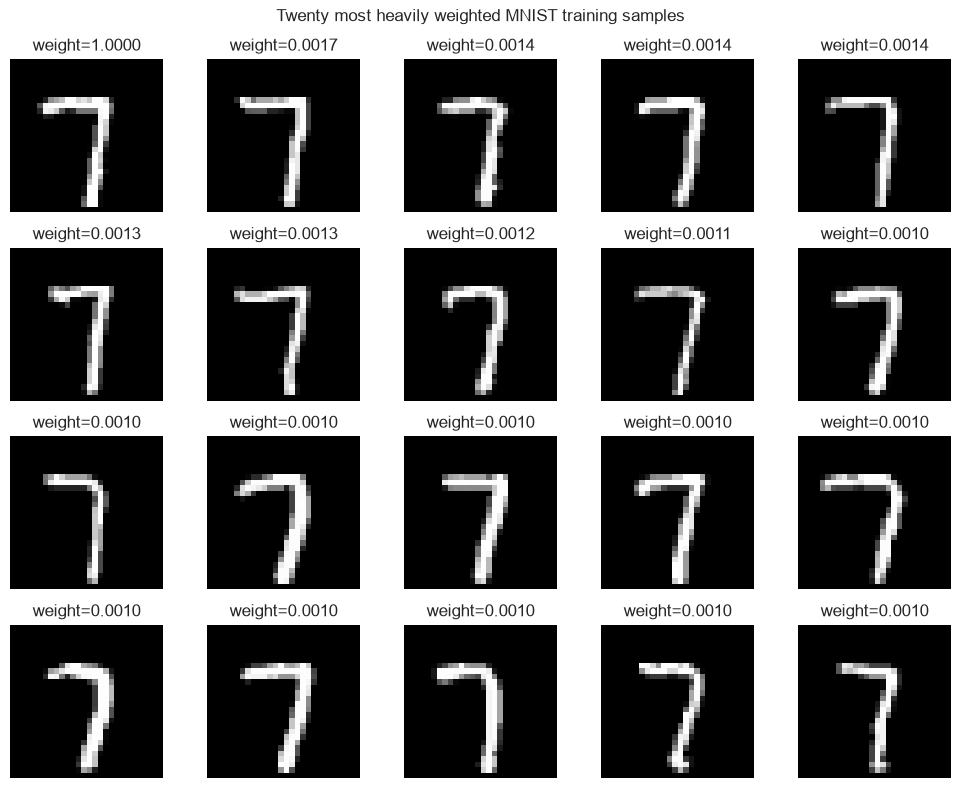

In [31]:
all_local_weights = calculate_local_weights(
    samples=mnist_features_train.to_numpy(dtype=np.float64)
)
most_local_positions = np.argsort(a=all_local_weights)[-20:][::-1]

figure, axes = plt.subplots(nrows=4, ncols=5, figsize=(10, 8))
for axis, sample_position in zip(axes.ravel(), most_local_positions):
    axis.imshow(
        X=mnist_features_train.iloc[int(sample_position)].to_numpy().reshape(28, 28),
        cmap="gray",
    )
    axis.set_title(f"weight={all_local_weights[int(sample_position)]:.4f}")
    axis.axis("off")
figure.suptitle("Twenty most heavily weighted MNIST training samples")
figure.tight_layout()
plt.show()

```for every digit, do the following:```
- ```take a sample of it from the dataset.```
- ```Our interpretable model is going to be a decision tree with max_depth = 5. Create the model.```
- ```Train it using the weights derived from the sample picked and the predictions of the complex LGBMClassifier model.```
- ```Create an empty image, and paint it by the feature_importance of each pixel, which you can get from the interpretable model.```
- ```Paint the image. Can you learn something from the image?```

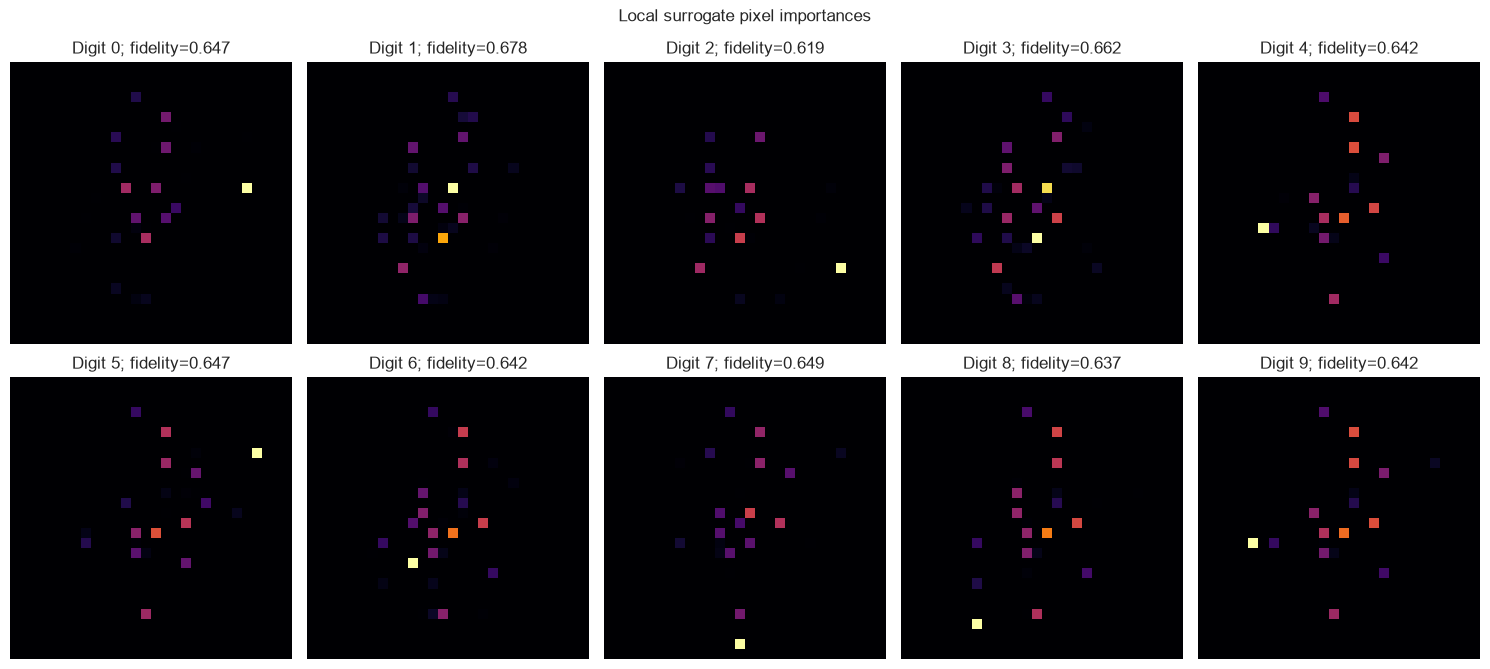

Mean locality-weighted surrogate fidelity: 0.6464


In [32]:
figure, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 7))
local_surrogate_fidelities = []

for digit_value, axis in zip(range(10), axes.ravel()):
    digit_index = mnist_target_train[mnist_target_train == digit_value].index[0]
    digit_reference = mnist_features_train.loc[digit_index].to_numpy(dtype=np.float64)
    digit_weight_function = make_local_weight_function(reference_sample=digit_reference)
    digit_train_weights = digit_weight_function(
        samples=mnist_features_train.to_numpy(dtype=np.float64)
    )
    digit_test_weights = digit_weight_function(
        samples=mnist_features_test.to_numpy(dtype=np.float64)
    )

    local_surrogate = DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_SEED,
    )
    local_surrogate.fit(
        X=mnist_features_train,
        y=interpretable_target_train,
        sample_weight=digit_train_weights,
    )
    local_surrogate_fidelity = accuracy_score(
        y_true=interpretable_target_test,
        y_pred=local_surrogate.predict(X=mnist_features_test),
        sample_weight=digit_test_weights,
    )
    local_surrogate_fidelities.append(local_surrogate_fidelity)
    axis.imshow(
        X=local_surrogate.feature_importances_.reshape(28, 28),
        cmap="inferno",
    )
    axis.set_title(f"Digit {digit_value}; fidelity={local_surrogate_fidelity:.3f}")
    axis.axis("off")

figure.suptitle("Local surrogate pixel importances")
figure.tight_layout()
plt.show()
LOGGER.info(
    "Mean locality-weighted surrogate fidelity: %.4f",
    float(np.mean(a=local_surrogate_fidelities)),
)

**Answer.** Bright pixels are the locations used by each depth-5 surrogate to imitate LightGBM near the selected digit. They should be interpreted together with local fidelity because a clear-looking map is unreliable when the surrogate fits the black box poorly.

```What are the biggest problems in LIME? What makes it limited? Regard, in your answer, the way the concept of "locality" is defined.```

**Answer.** LIME is sensitive to the distance metric, scaling, kernel width, and sampled neighborhood. Raw-pixel Euclidean distance may not reflect perceptual similarity, correlated features make importance unstable, and a simple surrogate may have low local fidelity. It explains the model locally—not causality or global behavior.

```The field of interpreting models might be very important, especially when working with complex models or with unsupervised learning. This part was a small taste of it, and you are encouraged to ``` **deepen** ``` (see what I did here? :) ) your knowledge about it.```

In [33]:
LOGGER.info("Timestamped output files: %s", OUTPUT_DIRECTORY.resolve())

Timestamped output files: C:\Users\asherk\PycharmProjects\DS_Training\D - ML\supervised\exercise\outputs\exercise_4_20260825_172537
